# 2cm2 — how many metastable states, via the inverse-PCCA+ spectral gap

The per-dimension notebooks (`dim3/`..`dim6/`) each fix k up front and inspect that one
membership model. This notebook asks the question the other way round: **given a trained
chi, what does its Koopman spectrum say about the number of states**, without assuming it?

`amore.inverse_pcca` (`examples/isokann_benchmark/inverse_pcca.ipynb`) recovers the
Rayleigh-Ritz spectrum of the coarse propagator `Lambda_S = G_hat^{-1} C_hat` projected
onto span(chi) -- no full transfer matrix needed. On the triple-well benchmark (known
k_true=3), training chi deliberately **overparametrized** (k=6, twice the true count) still
recovers a spectrum with a clean gap after the 3rd eigenvalue, landing close to the known
reference. The same trick, applied here to 2cm2's already-trained k=3..6 softmax-ISA models
(`lib/run.py::get_model`, no retraining), is the closest thing to ground truth available for
a real trajectory with no known answer.


In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import torch

SRC = os.path.abspath(os.path.join("..", "..", "..", "src"))
LIB = os.path.abspath(os.path.join("..", "lib"))
sys.path.insert(0, SRC)
sys.path.insert(0, LIB)
import data, train, run
from amore.isokann import ChiNetMulti
from amore.inverse_pcca import inverse_pcca, group_conjugate_pairs, find_spectral_gap, plot_complex_plane

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TAU = 1.0   # 1 trajectory lag frame at data.LAG's default; the gap is about ratios, not
            # absolute physical time, so this arbitrary unit is fine for spectral-gap reading
plt.rcParams["figure.dpi"] = 120
print("device:", DEVICE)

device: cuda


## Lag=1 frame (the original dim3..dim6 lag, before this notebook's finding)

Load the k=3,4,5,6 models exactly as cached by `lib/run.py::get_model` -- no retraining --
evaluate chi at the anchors, propagate one lag step via the trained net on the lag-shifted
features, and read off `inverse_pcca`'s spectrum for each k.

In [2]:
feats = data.build_features(use_pbc=True, verbose=False)
D0n, Dtn, mu, sd = train.normalise(feats["D0"], feats["Dt"])
D0n = D0n.to(DEVICE); Dtn = Dtn.to(DEVICE)
N, F = D0n.shape; Kb = Dtn.shape[1]
print(f"lag={data.LAG} frame(s)  N anchors={N}  F features={F}  Kb(lag replicas)={Kb}")

def load_net(k, F=F):
    m = torch.load(run.model_cache(k), weights_only=False)
    net = ChiNetMulti(F, k, hidden=m["hidden"]).to(DEVICE)
    net.load_state_dict(m["net_state"]); net.eval()
    return net

def eval_chi(net, D0n=D0n):
    with torch.no_grad():
        return net(D0n).cpu().numpy()

def make_propagate(net, Dtn=Dtn, N=N, F=F, Kb=Kb):
    def propagate():
        with torch.no_grad():
            flat = Dtn.reshape(N * Kb, F)
            return net(flat).reshape(N, Kb, -1).mean(1).cpu().numpy()
    return propagate

results_lag1 = {}
for k in [3, 4, 5, 6]:
    net = load_net(k)
    chi = eval_chi(net)
    result = inverse_pcca(chi, make_propagate(net), TAU, reversible=True)
    results_lag1[k] = (chi, result)
    lam = np.sort(np.abs(result.lam))[::-1]
    ts = np.sort(result.timescales[np.isfinite(result.timescales)])[::-1]
    print(f"k={k}  chi std/output: {chi.std(0).round(3)}  |lambda|: {lam.round(4)}  "
          f"residual(RMS/entry)={result.residual/np.sqrt(chi.size):.4f}")
    print(f"      timescales (frames): {ts.round(1)}")

lag=1 frame(s)  N anchors=1650  F features=40470  Kb(lag replicas)=1


k=3  chi std/output: [0.378 0.455 0.401]  |lambda|: [1.     0.998  0.9975]  residual(RMS/entry)=0.0273
      timescales (frames): [495.2 401. ]


k=4  chi std/output: [0.293 0.442 0.323 0.37 ]  |lambda|: [1.     0.9978 0.9932 0.9894]  residual(RMS/entry)=0.0368
      timescales (frames): [460.2 146.5  93.9]


k=5  chi std/output: [0.289 0.382 0.348 0.308 0.381]  |lambda|: [1.     0.9968 0.9968 0.9928 0.9891]  residual(RMS/entry)=0.0342
      timescales (frames): [316.5 316.5 137.6  90.9]


k=6  chi std/output: [0.194 0.321 0.302 0.332 0.415 0.379]  |lambda|: [1.     0.999  0.9947 0.9928 0.9928 0.9849]  residual(RMS/entry)=0.0344
      timescales (frames): [952.5 187.8 137.8 137.8  65.8]


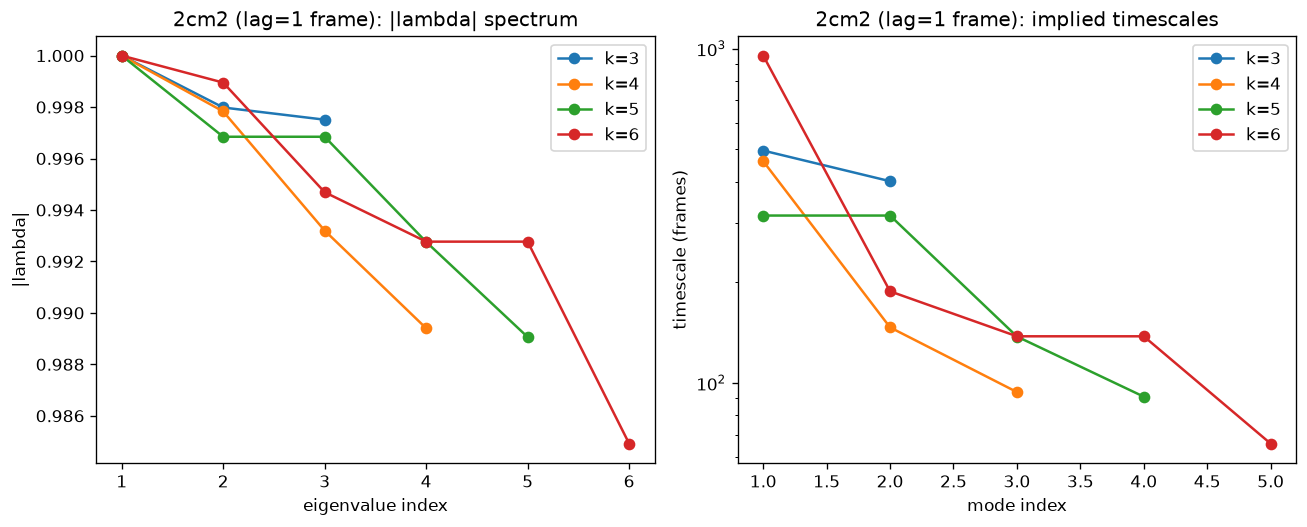

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for k, (chi, result) in results_lag1.items():
    lam = np.sort(np.abs(result.lam))[::-1]
    ts = np.sort(result.timescales[np.isfinite(result.timescales)])[::-1]
    axes[0].plot(np.arange(1, len(lam)+1), lam, "o-", label=f"k={k}")
    axes[1].plot(np.arange(1, len(ts)+1), ts, "o-", label=f"k={k}")
axes[0].set_xlabel("eigenvalue index"); axes[0].set_ylabel("|lambda|")
axes[0].set_title("2cm2 (lag=1 frame): |lambda| spectrum"); axes[0].legend()
axes[1].set_xlabel("mode index"); axes[1].set_ylabel("timescale (frames)"); axes[1].set_yscale("log")
axes[1].set_title("2cm2 (lag=1 frame): implied timescales"); axes[1].legend()
fig.tight_layout(); plt.savefig("spectral_gap_lag1.png", dpi=150, bbox_inches="tight"); plt.show()

**No gap at lag=1.** Every recovered `|lambda|` across k=3..6 sits inside `[0.985, 1.0]`
-- compressed, not stepped -- and the leading recovered timescale is *unstable* across k (it
does not converge to a common value as k grows, unlike the triple-well k=6/10 case in
`inverse_pcca.ipynb`). That instability is diagnostic: near `|lambda|=1`,
`t = -tau/log|lambda|` is ill-conditioned (tiny differences in a noisy `lambda` blow up into
large differences in timescale), and it is the fingerprint of lag=1 frame being too short
relative to *every* relaxation process in the system: for any process with true relaxation
time `t`, `lambda = exp(-tau/t) ~= 1` whenever `tau << t`. With one frame of lag, fast and
slow modes alike land near 1, so there is nothing for the gap to separate. The fix is not
more `k` at this lag -- it's a longer lag, so that faster modes decay visibly while the true
slow modes stay near 1.


## Lag=20 frames

Recompute the Koopman pairs at `CM2_LAG=20` (still a single trajectory pass -- `data.py`
caches per-lag) and retrain **one** overparametrized model, k=6, at the new lag -- reusing
the exact same `train.py` / `run.py` entry point, just a different `CM2_LAG`. We don't need
to sweep k=3..6 again: the whole point of the overparametrization trick is that a single
sufficiently-large k already reveals the gap.


In [4]:
data.LAG = 20   # data.py / run.py both read data.LAG dynamically at call time, so this
                # repoints build_features()'s cache path and model_cache()'s cache path
                # together, without re-importing the module.
feats20 = data.build_features(use_pbc=True, verbose=False)
D0n20, Dtn20, _, _ = train.normalise(feats20["D0"], feats20["Dt"])
D0n20 = D0n20.to(DEVICE); Dtn20 = Dtn20.to(DEVICE)
N20, F20 = D0n20.shape; Kb20 = Dtn20.shape[1]
print(f"lag={data.LAG}: N anchors={N20}  F features={F20}")

net20 = load_net(6, F=F20)
chi20 = eval_chi(net20, D0n=D0n20)
print(f"chi std/output: {chi20.std(0).round(3)}  (k_eff={(chi20.std(0) > 0.05).sum()})")

propagate20 = make_propagate(net20, Dtn=Dtn20, N=N20, F=F20, Kb=Kb20)
try:
    result20 = inverse_pcca(chi20, propagate20, TAU, reversible=True)
    print("reversible=True succeeded")
except ValueError as e:
    print(f"reversible=True failed ({e})\n-> falling back to reversible=False (Schur route):"
          " a single un-resampled trajectory need not satisfy empirical detailed balance,"
          " especially at a longer lag where the one-sample K_tau chi estimate is noisier.")
    result20 = inverse_pcca(chi20, propagate20, TAU, reversible=False)

lag1_k6_residual = results_lag1[6][1].residual / np.sqrt(results_lag1[6][0].size)
print(f"Lambda_S row sums: {result20.Lambda_S.sum(1).round(4)}")
print(f"residual: {result20.residual:.4f}  (RMS/entry={result20.residual/np.sqrt(chi20.size):.4f})"
      f"   [lag=1, k=6 residual RMS/entry was {lag1_k6_residual:.4f} for comparison]")
print()

processes20 = group_conjugate_pairs(result20.lam)
print(f"  {'Re':>9} {'Im':>9} {'|lambda|':>9}  kind")
for p in processes20:
    print(f"  {p.lam.real:+9.5f} {p.lam.imag:+9.5f} {p.modulus:9.5f}  {p.kind}")
print()
gap20 = find_spectral_gap(processes20)
print(f"spectral gap: {gap20.k} process(es) above it "
      f"({gap20.modulus_above:.4f} -> {gap20.modulus_below:.4f}, drop={gap20.gap:.4f})")

lag=20: N anchors=1650  F features=40470


chi std/output: [0.377 0.308 0.409 0.312 0.07  0.282]  (k_eff=6)
reversible=True failed (inverse_pcca(reversible=True): Lambda_S has a non-negligible imaginary eigenvalue component (max |Im| = 2.697e-02) -- this looks non-reversible; call with reversible=False.)
-> falling back to reversible=False (Schur route): a single un-resampled trajectory need not satisfy empirical detailed balance, especially at a longer lag where the one-sample K_tau chi estimate is noisier.


Lambda_S row sums: [1. 1. 1. 1. 1. 1.]
residual: 7.0751  (RMS/entry=0.0711)   [lag=1, k=6 residual RMS/entry was 0.0344 for comparison]

         Re        Im  |lambda|  kind
   +1.00797  +0.01028   1.00802  complex_pair
   +1.00000  +0.00000   1.00000  real
   +0.94205  +0.02697   0.94243  complex_pair
   +0.30881  +0.00000   0.30881  real

spectral gap: 3 process(es) above it (0.9424 -> 0.3088, drop=0.6336)


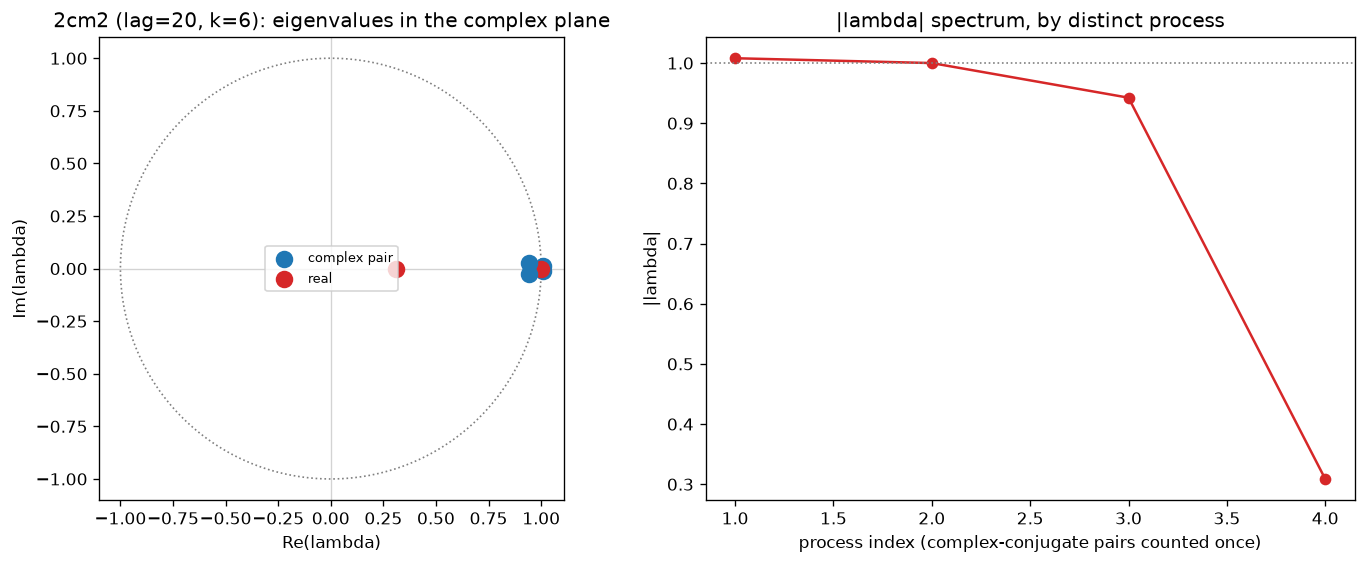

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

plot_complex_plane(axes[0], result20.lam)
axes[0].set_title("2cm2 (lag=20, k=6): eigenvalues in the complex plane")

ax = axes[1]
moduli20 = [p.modulus for p in processes20]
ax.plot(np.arange(1, len(moduli20)+1), moduli20, "o-", color="C3")
ax.axhline(1.0, color="gray", lw=1, ls=":")
ax.set_xlabel("process index (complex-conjugate pairs counted once)"); ax.set_ylabel("|lambda|")
ax.set_title("|lambda| spectrum, by distinct process")
fig.tight_layout(); plt.savefig("spectral_gap_lag20.png", dpi=150, bbox_inches="tight"); plt.show()

**A gap appears, with real caveats.** Unlike lag=1, the lag=20 spectrum is no longer
compressed near 1 -- there's a visible drop after the leading cluster down to the last
recovered value. But reading that gap as a state count needs care, for three reasons:

1. **Two of the six raw eigenvalue slots are a single genuine complex-conjugate pair each**
   (`Re` equal, `Im` opposite sign -- printed and grouped explicitly above), not four
   independent real values. Counting *distinct physical processes* rather than raw array
   positions: `{Perron, complex pair @ ~1.008, complex pair @ ~0.942}` sit above the gap
   (**3** processes: 1 stationary + 2 non-trivial, one of them oscillatory) and the real
   mode at `|lambda|=0.309` sits below it. Treating each half of a pair as its own "state"
   would over-count by up to 2.
2. `reversible=True` **fails outright** here (non-negligible imaginary component in
   `Lambda_S`), so this used the non-reversible Schur route. That's plausible, not
   alarming: 2cm2's Koopman pairs are a *single* un-resampled trajectory (`N_REP=1`, no
   parallel bursts to average), so the empirical transition estimate need not satisfy
   detailed balance exactly at any finite sample size -- and a longer lag means fewer
   effectively-independent transitions, making that finite-sample asymmetry more visible
   (it was likely present at lag=1 too, just masked by every `lambda` sitting near 1).
3. The invariance residual roughly **doubles** vs. lag=1 (RMS/entry ~0.07 vs ~0.03), and
   the `~1.008` pair sits fractionally *above* 1 -- not achievable for a true
   Koopman/transfer operator, so it is likely a noise-inflated split of something closer
   to the Perron mode rather than a fully independent second slow process. That pulls the
   honest count down toward 2-3 processes, not a confident 3.

**A consequence for future k=3 training**: `examples/isokann_benchmark/nonreversible.ipynb`
(section 6, "ISOKANN returns the real membership without forming the eigenfunctions")
already establishes the relevant mechanism, and it's more precise than "real memberships
can't represent a rotation" -- **they can, and training stays real end to end regardless
of reversibility.** ISOKANN/ISA never forms the complex eigenfunctions during training;
chi is real throughout, and the complex-conjugate pair only appears *post-hoc*, as an
eigenvalue of the reduced Koopman matrix in the learned basis -- exactly the
`inverse_pcca` step used above, not anything chi itself has to represent. That notebook's
own ring benchmark confirms it empirically: plain **ISA already "nails" the ring** (high
fate AUROC, recovers the forward committor) with no Schur route needed for training to
succeed -- Schur-ISA's role there is repairing a *feasibility* issue (plain ISA's
inner-simplex memberships go slightly negative on a cycle: "a triangle cannot tile a
circle"), not fixing a training failure.

The actual risk is narrower and different: **choosing a k that bisects a complex pair's
required 2-real-dimensional invariant subspace.** Per that notebook's corollary, at the
correct k training converges to the real memberships directly from the lagged pairs; a
k that splits a pair instead **precesses and never stabilizes** -- diagnosable directly
(the network fails to settle, unlike neighboring k), not something that silently
mis-trains. So a k=3 retrain here would be expected to work fine *unless* 3 happens to
split whatever real invariant structure is actually present (e.g. if the honest count
really is "Perron + one complex pair," which needs exactly 2 real dimensions alongside
Perron -- i.e. k=3 exactly, not bisected -- so k=3 should in fact be a *feasible* choice
by this criterion). This is not tested here -- it would need retraining at k=3 and
checking for stabilization (no precession) rather than assuming a representational
limit that, per the above, does not exist.

Net: the lag diagnosis was right -- lag=1 hid all structure -- and lag=20 recovers some of
it, but this one run isn't precise enough to read off a definitive state count from.

### Follow-up: k=3 @ lag=20 (`../dim3/2cm2_isokann_dim3.ipynb`)

Acting on the reasoning above (k=3 = Perron + one complex pair, not bisected, so expected
to be a *feasible* choice), `dim3/` was retrained at lag=20 -- check that notebook's own
loss/chi trajectory for whether training stabilized (as expected) or precessed. dim4-6
(all lag=1, superseded by this notebook's finding) were dropped.

Other follow-ups not run here: average `K_tau chi` over several stochastic replicas per
anchor (2cm2 currently uses `N_REP=1`, a single lag image) to remove the one-sample Monte
Carlo noise in `C_hat`; sweep a few intermediate lags and check where the leading
cluster's `|lambda|` values *stabilize* across k, the same cross-k convergence check that
flagged lag=1 as unreliable in the first place, applied as a lag sweep instead.
